# **Into the Job Market: Gender Fairness in Recruitment Dataset**

Alkmini Sapountzaki (alks@itu.dk), Caroline Sofie Skovby (cssk@itu.dk), Miriam Espinosa Solana (miri@itu.dk)

## Table of Contents
* [Imports](#imports)
* [Explanatory Analysis](#explanatory-analysis)
* [Baseline Model](#baseline-model)
    * [Statistical Parity](#statistical-parity)
    * [Equalized Odds](#equalized-odds)
* [Modified Model](#modified-model)
    * [Statistical Parity](#statistical-parity-2)
    * [Equalized Odds](#equalized-odds-2)
    * [Shap Values](#shap-values)
* [Fair PCA](#fair-pca)
    * [Correlations in Data](#correlations-in-data)
    * [PCA](#pca)


## Imports <a class="anchor" id="imports"></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import shap 
import scipy


from scipy.stats import pearsonr
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import f1_score


In [2]:
# Load the data 
df = pd.read_csv('data/recruitmentdataset-2022.csv')
df.head()

,Id,gender,age,nationality,sport,ind-university_grade,ind-debateclub,ind-programming_exp,ind-international_exp,ind-entrepeneur_exp,ind-languages,ind-exact_study,ind-degree,company,decision
0,x8011e,female,24,German,Swimming,70,False,False,False,False,1,True,phd,A,True
1,x6077a,male,26,German,Golf,67,False,True,False,False,2,True,bachelor,A,False
2,x6006e,female,23,Dutch,Running,67,False,True,True,False,0,True,master,A,False
3,x2173b,male,24,Dutch,Cricket,70,False,True,False,False,1,True,master,A,True
4,x6241a,female,26,German,Golf,59,False,False,False,False,1,False,master,A,True


## Explanatory Analysis <a class="anchor" id="explanatory-analysis"></a>

In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Id                     4000 non-null   object
 1   gender                 4000 non-null   object
 2   age                    4000 non-null   int64 
 3   nationality            4000 non-null   object
 4   sport                  4000 non-null   object
 5   ind-university_grade   4000 non-null   int64 
 6   ind-debateclub         4000 non-null   bool  
 7   ind-programming_exp    4000 non-null   bool  
 8   ind-international_exp  4000 non-null   bool  
 9   ind-entrepeneur_exp    4000 non-null   bool  
 10  ind-languages          4000 non-null   int64 
 11  ind-exact_study        4000 non-null   bool  
 12  ind-degree             4000 non-null   object
 13  company                4000 non-null   object
 14  decision               4000 non-null   bool  
dtypes: bool(6), int64(3),

In [70]:
df['gender'].value_counts()

gender
male      2127
female    1790
other       83
Name: count, dtype: int64

In [71]:
df['nationality'].value_counts()

nationality
Dutch      3167
Belgian     434
German      399
Name: count, dtype: int64

In [72]:
df['sport'].value_counts()

sport
Football    889
Swimming    689
Rugby       675
Tennis      443
Chess       365
Golf        323
Running     309
Cricket     307
Name: count, dtype: int64

In [73]:
df['ind-languages'].value_counts() # number of additional languages known by the candidates

ind-languages
1    1639
2    1349
0     676
3     336
Name: count, dtype: int64

<Axes: xlabel='company'>

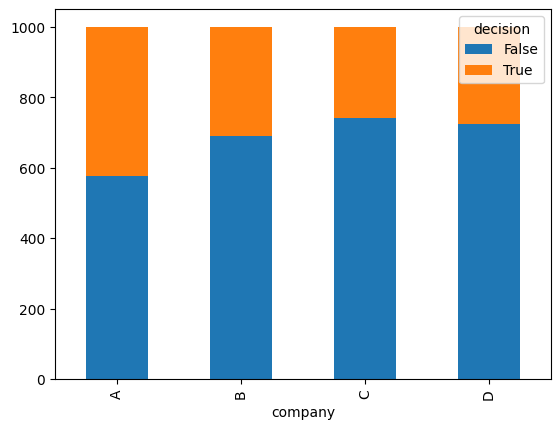

In [74]:
df.groupby(['company','decision']).size().unstack().plot(kind='bar', stacked=True)

<Axes: xlabel='gender'>

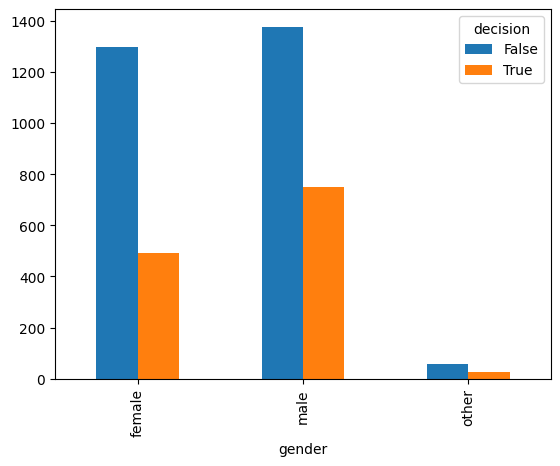

In [75]:
df.groupby(['gender', 'decision']).size().unstack().plot(kind='bar', stacked=False)

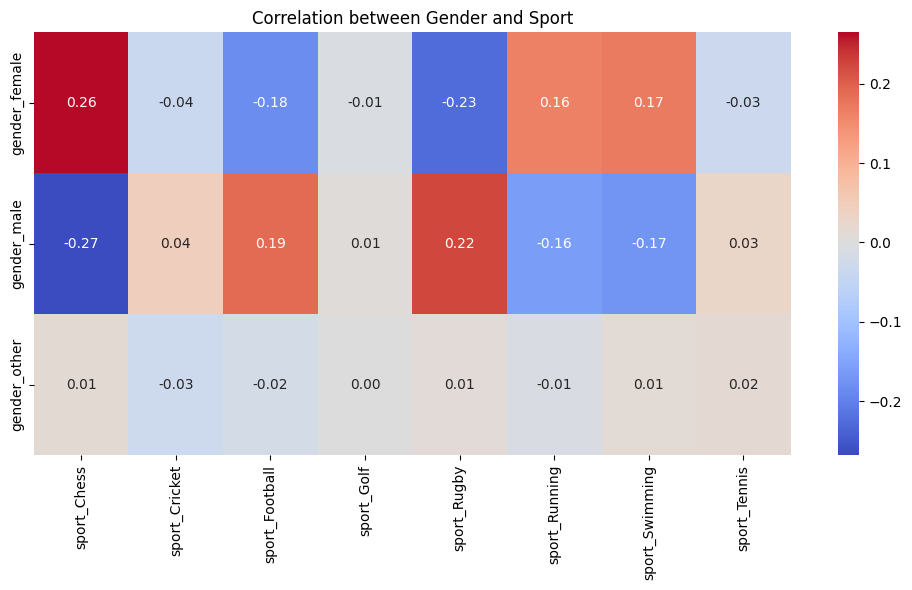

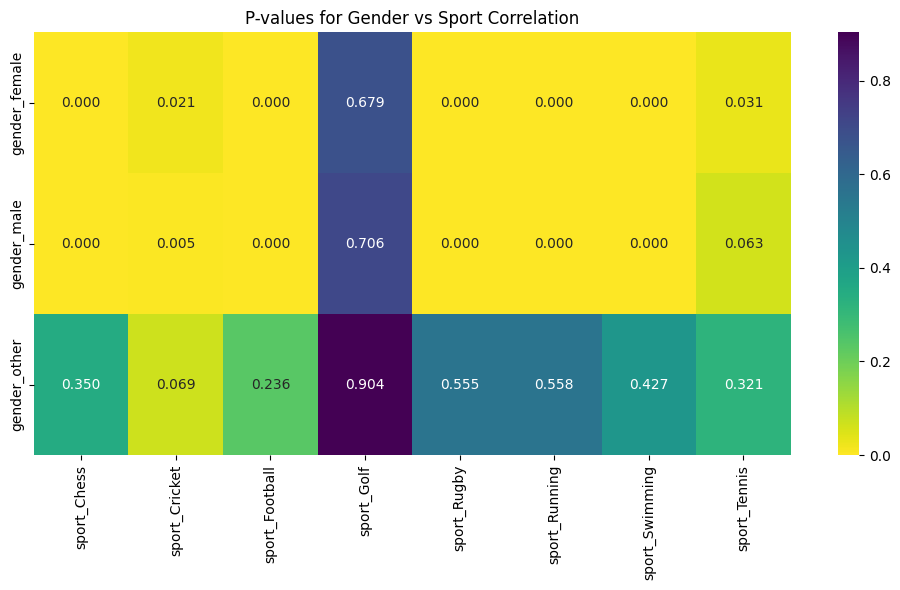

In [3]:
# One-hot encode
df_encoded = pd.get_dummies(df[['gender', 'sport']])

# Identify columns
gender_cols = [col for col in df_encoded.columns if col.startswith('gender_')]
sport_cols = [col for col in df_encoded.columns if col.startswith('sport_')]

# Create empty DataFrames
corr_matrix = pd.DataFrame(index=gender_cols, columns=sport_cols)
pval_matrix = pd.DataFrame(index=gender_cols, columns=sport_cols)

# Compute correlation + p-values
for g in gender_cols:
    for s in sport_cols:
        r, p = pearsonr(df_encoded[g].astype(int), df_encoded[s].astype(int))
        corr_matrix.loc[g, s] = r
        pval_matrix.loc[g, s] = p

# Convert to float
corr_matrix = corr_matrix.astype(float)
pval_matrix = pval_matrix.astype(float)

# Plot correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt=".2f"
)
plt.title("Correlation between Gender and Sport")
plt.tight_layout()
plt.show()

# (Optional) Plot p-values heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(
    pval_matrix,
    annot=True,
    cmap='viridis_r',
    fmt=".3f"
)
plt.title("P-values for Gender vs Sport Correlation")
plt.tight_layout()
plt.show()

<Axes: >

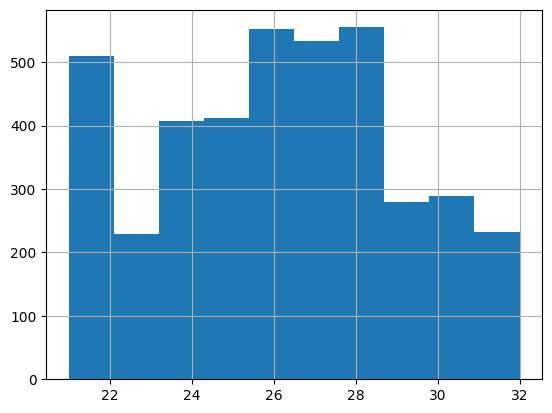

In [77]:
df['age'].hist()

<Axes: >

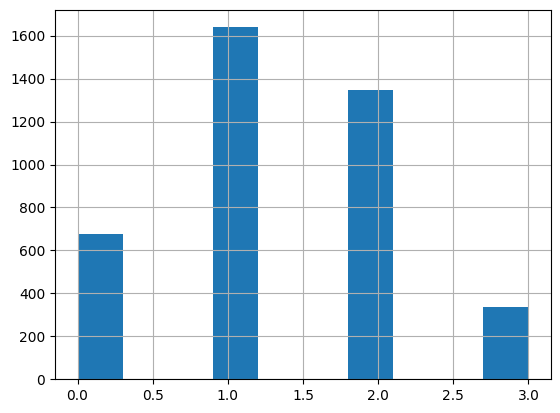

In [78]:
df['ind-languages'].hist()

In [4]:
percent_chosen = df.groupby('gender')['decision'].mean() * 100

percent_chosen = percent_chosen.reset_index()
percent_chosen.columns = ['gender', 'percent_chosen']

percent_chosen

,gender,percent_chosen
0,female,27.486034
1,male,35.260931
2,other,30.120482


## Baseline Model <a class="anchor" id="baseline-model"></a>

In [5]:
feature_names = [#'Id', # Id
                 "gender", # Gender - sensitive
                 'age', # age in years 
                 "nationality", # Nationality
                 'sport', # first/main sport listed on CV
                 'ind-university_grade', # University grade (percentage) of the canditate
                 "ind-debateclub", # whether candidate participated in debate club
                 "ind-programming_exp", # whether candidate has programming experience
                 'ind-international_exp', # whether candidate has international experience
                 "ind-entrepeneur_exp", # whether candidate has entrepeneur experience
                 "ind-languages", # Number of additional languages spoken fluently by candidate
                 'ind-exact_study', # whether candidate studied physics, engineering or other science-oriented study
                 'ind-degree', # highest completed degree. Phd, bachelor or master level
                 'company'] # The company the candidate applied to

target_name = "decision" # target value - wether the candidate got hired at the company or not

def data_processing(data, features, target_name:str):
    df = data
    ### Gender Filter
    df = df[df["gender"] != 'other'] # filter out 'other', to have binary gender

    ### Groups of interest
    sex = df["gender"].values

    ### Target
    df["target"] = df[target_name] # decision is target value
    target = df["target"].values
    df = df[features + ["target", target_name]] #we want to keep df before one_hot encoding to make Bias Analysis - probably not relevant with decision being binary to begin with
    df_processed = df[features].copy()
    cols = [ "gender", "nationality", "sport", "ind-degree", "company"]
    df_processed = pd.get_dummies(df_processed, prefix=None, prefix_sep='_', dummy_na=False, columns=cols, drop_first=False)
    df_processed = df_processed.drop(columns=["sport_Football", "gender_male", "nationality_Dutch", "ind-degree_bachelor", "company_A"])
    return df_processed, df, target, sex

data, data_original, target, group = data_processing(df, feature_names, target_name)

X_train, X_test, y_train, y_test, group_train, group_test = train_test_split(
    data, target, group, test_size=0.2, random_state=0)

C:\Users\Caroline Skovby\AppData\Local\Temp\ipykernel_76404\1112919351.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["target"] = df[target_name] # decision is target value


In [6]:
train_df = pd.DataFrame({
    'gender': group_train,
    'decision': y_train
})

percent_train = (
    train_df.groupby('gender')['decision'].mean() * 100
).reset_index(name='percent_chosen')

print(percent_train)

   gender  percent_chosen
0  female       27.731674
1    male       35.921755


In [7]:
test_df = pd.DataFrame({
    'gender': group_test,
    'decision': y_test
})

percent_test = (
    test_df.groupby('gender')['decision'].mean() * 100
).reset_index(name='percent_chosen')

print(percent_test)

   gender  percent_chosen
0  female       26.453488
1    male       32.727273


In [83]:
X_train.columns

Index(['age', 'ind-university_grade', 'ind-debateclub', 'ind-programming_exp',
       'ind-international_exp', 'ind-entrepeneur_exp', 'ind-languages',
       'ind-exact_study', 'gender_female', 'nationality_Belgian',
       'nationality_German', 'sport_Chess', 'sport_Cricket', 'sport_Golf',
       'sport_Rugby', 'sport_Running', 'sport_Swimming', 'sport_Tennis',
       'ind-degree_master', 'ind-degree_phd', 'company_B', 'company_C',
       'company_D'],
      dtype='object')

In [8]:
num_col = ["age"]

preprocessor = ColumnTransformer(
    transformers=[("scale_agep", StandardScaler(), num_col)],
    remainder="passthrough",
    verbose_feature_names_out=False
)

Xtr = preprocessor.fit_transform(X_train)
Xte = preprocessor.transform(X_test)

feat_names = preprocessor.get_feature_names_out()

Xtr_df = pd.DataFrame(Xtr, columns=feat_names, index=X_train.index)
Xte_df = pd.DataFrame(Xte, columns=feat_names, index=X_test.index)

In [9]:
log = LogisticRegression(max_iter=5000, penalty="l2")  
log.fit(Xtr, y_train)

beta = np.r_[log.intercept_, log.coef_.ravel()]

In [10]:
y_pred_logistic = log.predict(Xte)   

In [11]:
accuracy = log.score(Xte, y_test)
print(f'accuracy scale: {accuracy}')

accuracy scale: 0.7346938775510204


In [12]:
df_logistic = Xte_df
df_logistic['pred'] = y_pred_logistic
df_logistic['target'] = y_test

### Statistical Parity <a id="statistical-parity"></a>

$\Pr(S = 1 \mid G = 1) = \Pr(S = 1 \mid G = 0)$

In [13]:
group_male_label = False
group_fem_label = not group_male_label

group_col = 'gender_female'
selection_col = 'pred'
target_col = 'target'

In [14]:
def statistical_parity(df, group):
    current_group = df[df[group_col] == group]
    true_current_group = current_group[current_group[selection_col]]
    return true_current_group.shape[0]/current_group.shape[0]

In [15]:
fem_sp_bef = statistical_parity(df_logistic, group=group_fem_label)
male_sp_bef = statistical_parity(df_logistic, group=group_male_label)

print(f'fem: {fem_sp_bef}')
print(f'male: {male_sp_bef}')
print(f'ratio (fem/male): {fem_sp_bef/male_sp_bef}')

stats_parity_diff = male_sp_bef - fem_sp_bef

print(f'Difference in sts. parity: {stats_parity_diff}')

fem: 0.13372093023255813
male: 0.30227272727272725
ratio (fem/male): 0.4423850323483126
Difference in sts. parity: 0.16855179704016912


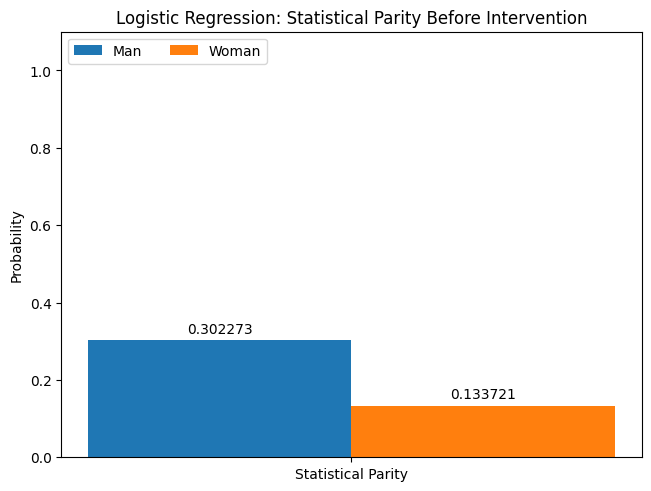

In [16]:
labels = ["Statistical Parity"]
medians = {
    'Man': male_sp_bef,
    'Woman': fem_sp_bef
}

x = np.arange(len(labels))
width = 0.2
multiplier = 0

fig, ax = plt.subplots(layout='constrained')

for attribute, measurement in medians.items():
    offset = width*multiplier
    rects = ax.bar(x + offset, measurement, width, label=attribute)
    ax.bar_label(rects, padding=3)
    multiplier += 1

ax.set_ylabel('Probability')
ax.set_title('Logistic Regression: Statistical Parity Before Intervention')
ax.set_xticks(x+width /2)
ax.set_xticklabels(labels)
ax.legend(loc='upper left', ncols=3)
ax.set_ylim(0, 1.1)

plt.show()

### Equalized Odds <a id="equalized-odds"></a>

$\Pr(S = 1 \mid G = 1, T = 1) = \Pr(S = 1 \mid G = 0, T = 1)$

$\Pr(S = 1 \mid G = 1, T = 0) = \Pr(S = 1 \mid G = 0, T = 0)$

In [17]:
def equalized_odds(df, group, target):
    current_group_target = df[(df[group_col] == group) & (df[target_col] == target)]
    current_group_target_selected = current_group_target[current_group_target[selection_col]]
    return current_group_target_selected.shape[0]/current_group_target.shape[0]

In [18]:
fem_eo_true_bef = equalized_odds(df_logistic, group_fem_label, target=True)
male_eo_true_bef = equalized_odds(df_logistic, group_male_label, target=True)

print(f'fem: {fem_eo_true_bef}')
print(f'male: {male_eo_true_bef}')
print(f'ratio (fem/male): {fem_eo_true_bef/male_eo_true_bef}')

fem: 0.27472527472527475
male: 0.5416666666666666
ratio (fem/male): 0.507185122569738


In [19]:
fem_eo_false_bef = equalized_odds(df_logistic, group_fem_label, target=False)
male_eo_false_bef = equalized_odds(df_logistic, group_male_label, target=False)

print(f'fem: {fem_eo_false_bef}')
print(f'male: {male_eo_false_bef}')
print(f'ratio (fem/male): {fem_eo_false_bef/male_eo_false_bef}')

fem: 0.08300395256916997
male: 0.1858108108108108
ratio (fem/male): 0.4467121810995329


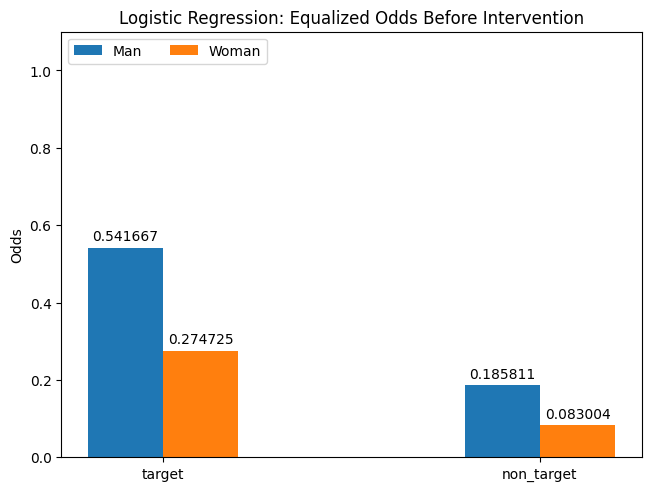

In [20]:
labels = ("target", "non_target")
medians = {
    'Man': (male_eo_true_bef, male_eo_false_bef),
    'Woman': (fem_eo_true_bef, fem_eo_false_bef)
}


x = np.arange(len(labels))
width = 0.2
multiplier = 0

fig, ax = plt.subplots(layout='constrained')

for attribute, measurement in medians.items():
    offset = width*multiplier
    rects = ax.bar(x + offset, measurement, width, label=attribute)
    ax.bar_label(rects, padding=3)
    multiplier += 1

ax.set_ylabel('Odds')
ax.set_title('Logistic Regression: Equalized Odds Before Intervention')
ax.set_xticks(x+width/2, labels)
ax.legend(loc='upper left', ncols=3)
ax.set_ylim(0, 1.1)

plt.show()

## Modified Model <a class="anchor" id="modified-model"></a>

In [21]:
X_train.columns

Index(['age', 'ind-university_grade', 'ind-debateclub', 'ind-programming_exp',
       'ind-international_exp', 'ind-entrepeneur_exp', 'ind-languages',
       'ind-exact_study', 'gender_female', 'nationality_Belgian',
       'nationality_German', 'sport_Chess', 'sport_Cricket', 'sport_Golf',
       'sport_Rugby', 'sport_Running', 'sport_Swimming', 'sport_Tennis',
       'ind-degree_master', 'ind-degree_phd', 'company_B', 'company_C',
       'company_D'],
      dtype='object')

In [22]:
X_test.columns

Index(['age', 'ind-university_grade', 'ind-debateclub', 'ind-programming_exp',
       'ind-international_exp', 'ind-entrepeneur_exp', 'ind-languages',
       'ind-exact_study', 'gender_female', 'nationality_Belgian',
       'nationality_German', 'sport_Chess', 'sport_Cricket', 'sport_Golf',
       'sport_Rugby', 'sport_Running', 'sport_Swimming', 'sport_Tennis',
       'ind-degree_master', 'ind-degree_phd', 'company_B', 'company_C',
       'company_D'],
      dtype='object')

In [23]:
X_train_no_gender = X_train.drop(columns= ["gender_female"])
X_test_no_gender = X_test.drop(columns= ["gender_female"])

num_col = ["age"]

Xtr_no_gender = preprocessor.fit_transform(X_train_no_gender)
Xte_no_gender = preprocessor.transform(X_test_no_gender)

feat_names = preprocessor.get_feature_names_out()

Xtr_df_no_gender = pd.DataFrame(Xtr_no_gender, columns=feat_names, index=X_train_no_gender.index)
Xte_df_no_gender = pd.DataFrame(Xte_no_gender, columns=feat_names, index=X_test_no_gender.index)

log_no_gender = LogisticRegression(max_iter=5000, penalty="l2")  
log_no_gender.fit(Xtr_no_gender, y_train)

beta = np.r_[log_no_gender.intercept_, log_no_gender.coef_.ravel()]

y_pred_logistic_no_gender = log_no_gender.predict(Xte_no_gender)   

accuracy_no_gender = log_no_gender.score(Xte_no_gender, y_test)
print(f'accuracy scale: {accuracy_no_gender}')

df_logistic_no_gender = X_test.copy()
df_logistic_no_gender['pred_no_gender'] = y_pred_logistic_no_gender
df_logistic_no_gender['target'] = y_test

# df_logistic_no_gender = Xte_df_no_gender
# df_logistic_no_gender['pred_no_gender'] = y_pred_logistic_no_gender
# df_logistic_no_gender['target'] = y_test

accuracy scale: 0.7372448979591837


### Statistical Parity <a id="statistical-parity-2"></a>

In [24]:
selection_col = 'pred_no_gender'

fem_sp_bef_no_gender = statistical_parity(df_logistic_no_gender, group=group_fem_label)
male_sp_bef_no_gender = statistical_parity(df_logistic_no_gender, group=group_male_label)

print(f'fem: {fem_sp_bef_no_gender}')
print(f'male: {male_sp_bef_no_gender}')
print(f'ratio (fem/male): {fem_sp_bef_no_gender/male_sp_bef_no_gender}')

stats_parity_diff_no_gender = male_sp_bef_no_gender - fem_sp_bef_no_gender

print(f'Difference in sts. parity: {stats_parity_diff_no_gender}')

fem: 0.13953488372093023
male: 0.29318181818181815
ratio (fem/male): 0.47593293672255277
Difference in sts. parity: 0.15364693446088792


In [25]:
print(f'Difference in sts. parity: {stats_parity_diff}')

Difference in sts. parity: 0.16855179704016912


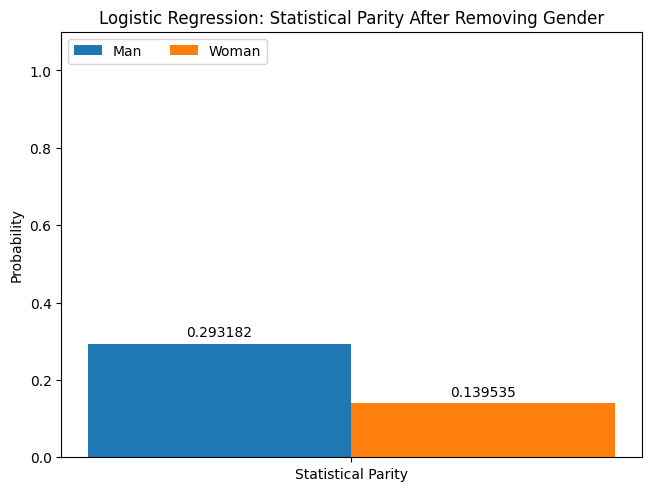

In [26]:
labels = ["Statistical Parity"]
medians = {
    'Man': male_sp_bef_no_gender,
    'Woman': fem_sp_bef_no_gender
}

x = np.arange(len(labels))
width = 0.2
multiplier = 0

fig, ax = plt.subplots(layout='constrained')

for attribute, measurement in medians.items():
    offset = width*multiplier
    rects = ax.bar(x + offset, measurement, width, label=attribute)
    ax.bar_label(rects, padding=3)
    multiplier += 1

ax.set_ylabel('Probability')
ax.set_title('Logistic Regression: Statistical Parity After Removing Gender')
ax.set_xticks(x+width /2)
ax.set_xticklabels(labels)
ax.legend(loc='upper left', ncols=3)
ax.set_ylim(0, 1.1)

plt.show()

### Equalized Odds <a id="equalized-odds-2"></a>

fem: 0.2967032967032967
male: 0.5277777777777778
ratio (fem/male): 0.5621746674378253
fem: 0.08300395256916997
male: 0.17905405405405406
ratio (fem/male): 0.4635692445372511


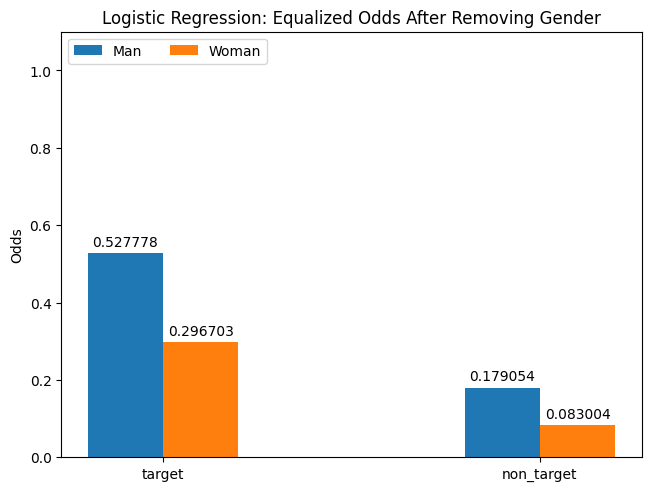

In [27]:
fem_eo_true_bef_no_gender = equalized_odds(df_logistic_no_gender, group_fem_label, target=True)
male_eo_true_bef_no_gender = equalized_odds(df_logistic_no_gender, group_male_label, target=True)

print(f'fem: {fem_eo_true_bef_no_gender}')
print(f'male: {male_eo_true_bef_no_gender}')
print(f'ratio (fem/male): {fem_eo_true_bef_no_gender/male_eo_true_bef_no_gender}')

fem_eo_false_bef_no_gender = equalized_odds(df_logistic_no_gender, group_fem_label, target=False)
male_eo_false_bef_no_gender = equalized_odds(df_logistic_no_gender, group_male_label, target=False)

print(f'fem: {fem_eo_false_bef_no_gender}')
print(f'male: {male_eo_false_bef_no_gender}')
print(f'ratio (fem/male): {fem_eo_false_bef_no_gender/male_eo_false_bef_no_gender}')

labels = ("target", "non_target")
medians = {
    'Man': (male_eo_true_bef_no_gender, male_eo_false_bef_no_gender),
    'Woman': (fem_eo_true_bef_no_gender, fem_eo_false_bef_no_gender)
}


x = np.arange(len(labels))
width = 0.2
multiplier = 0

fig, ax = plt.subplots(layout='constrained')

for attribute, measurement in medians.items():
    offset = width*multiplier
    rects = ax.bar(x + offset, measurement, width, label=attribute)
    ax.bar_label(rects, padding=3)
    multiplier += 1

ax.set_ylabel('Odds')
ax.set_title('Logistic Regression: Equalized Odds After Removing Gender')
ax.set_xticks(x+width/2, labels)
ax.legend(loc='upper left', ncols=3)
ax.set_ylim(0, 1.1)

plt.show()

### Shap Values <a id="shap-values"></a>


In [28]:
print("coef shape:", log.coef_.shape) 
print("Xtr_df:", Xtr_df.shape)
print("Xte_df:", Xte_df.shape)

coef shape: (1, 23)
Xtr_df: (3133, 23)
Xte_df: (784, 25)


In [29]:
Xte_df_shap = Xte_df.drop(columns=["pred", "target"])

In [30]:
model = log
explainer = shap.Explainer(model,masker=Xtr_df, model_output='probability')
shap_values = explainer(Xte_df_shap)

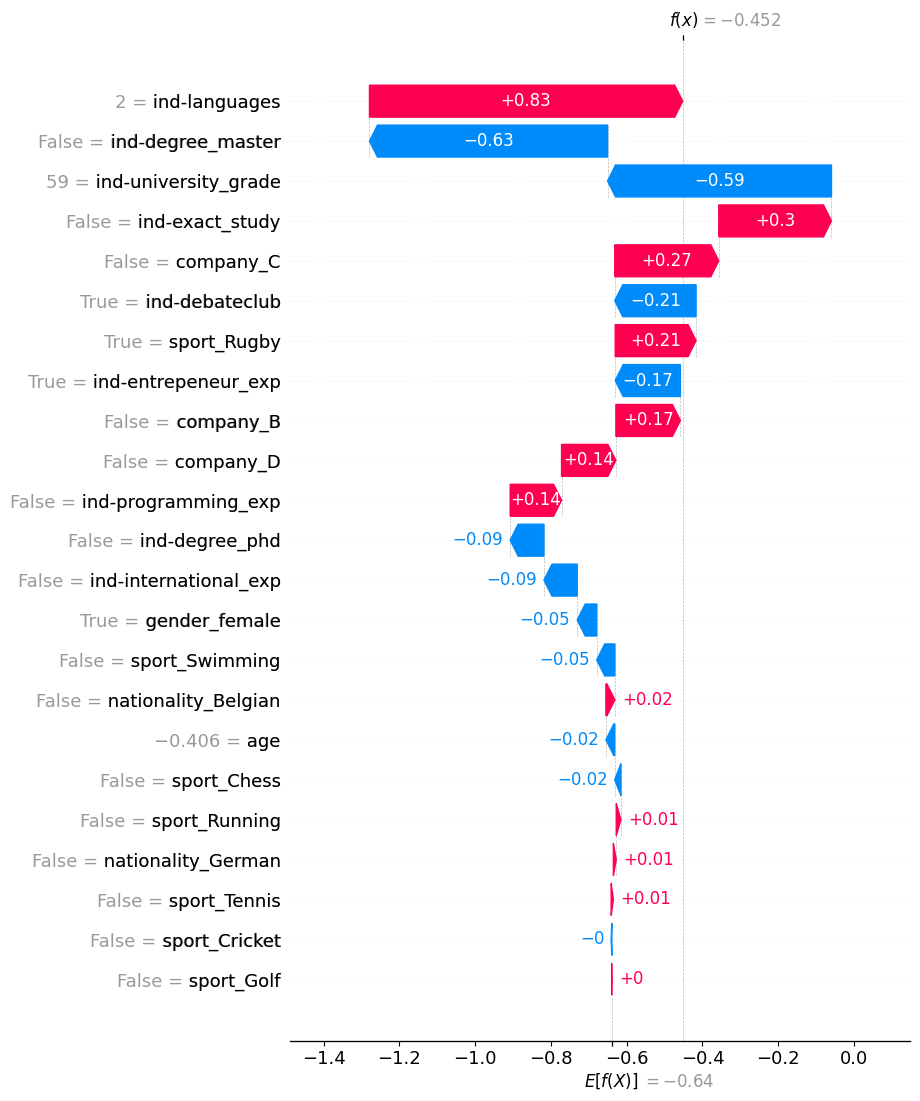

In [31]:
shap.waterfall_plot(shap_values[0], max_display=len(Xte_df_shap.columns))

## Fair PCA <a class="anchor" id="fair-pca"></a>


### Correlations in Data <a id="correlations-in-data"></a>

In [32]:
# Drop the "redundant" columns
print("Columns with the protected features:")
for i, f in enumerate(data.columns):
    if ("gender" in f):
        print("Column ID: %s" %i, "(%s)"%f)

Columns with the protected features:
Column ID: 8 (gender_female)


In [33]:
X_train_copy = X_train.copy()
print(type(X_train_copy))
X_test_copy = X_test.copy()
print(type(X_test_copy))

X_train_copy['gender'] = X_train_copy['gender_female']
X_test_copy['gender'] = X_test_copy['gender_female']

X_train_copy.drop(columns=["gender_female"], inplace=True)
X_test_copy.drop(columns=["gender_female"], inplace=True)

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>


In [34]:
# Scale all features (even OHE)
scaler = StandardScaler().fit(X_train_copy)
Xs_train = scaler.transform(X_train_copy)
Xs_test = scaler.transform(X_test_copy)
n_features = X_train_copy.shape[1]

In [35]:
Xs_train[:, 0] ## age is standardized

array([-0.75937725, -1.4656646 ,  1.00634112, ..., -0.75937725,
       -0.75937725,  1.71262847])

In [36]:
Xs_train.shape

(3133, 23)

In [37]:
# Subset for protected and non-protected features
n = 22
Xs_train_p = Xs_train[:, n:]
Xs_test_p = Xs_test[:, n:]
Xs_train_np = Xs_train[:, :n]
Xs_test_np = Xs_test[:, :n]

In [38]:
Xs_train_np.shape

(3133, 22)

In [39]:
Xs_train_p.shape

(3133, 1)

In [40]:
n_features = X_train.shape[1]
alpha = 0.05 # Significance level
corrected_alpha = alpha / (n_features**2/2) # Bonferroni correction for multiple testings

# Compute correlation matrix
corr = np.zeros((n_features, n_features))
p = np.zeros((n_features, n_features))
for i in range(n_features):
    for j in range(n_features):
        corr[i,j], p[i,j] = pearsonr(Xs_train[:,i], Xs_train[:,j])
        if np.isnan(corr[i,j]):
            p[i,j] = 1

In [117]:
data.columns

Index(['age', 'ind-university_grade', 'ind-debateclub', 'ind-programming_exp',
       'ind-international_exp', 'ind-entrepeneur_exp', 'ind-languages',
       'ind-exact_study', 'gender_female', 'nationality_Belgian',
       'nationality_German', 'sport_Chess', 'sport_Cricket', 'sport_Golf',
       'sport_Rugby', 'sport_Running', 'sport_Swimming', 'sport_Tennis',
       'ind-degree_master', 'ind-degree_phd', 'company_B', 'company_C',
       'company_D'],
      dtype='object')

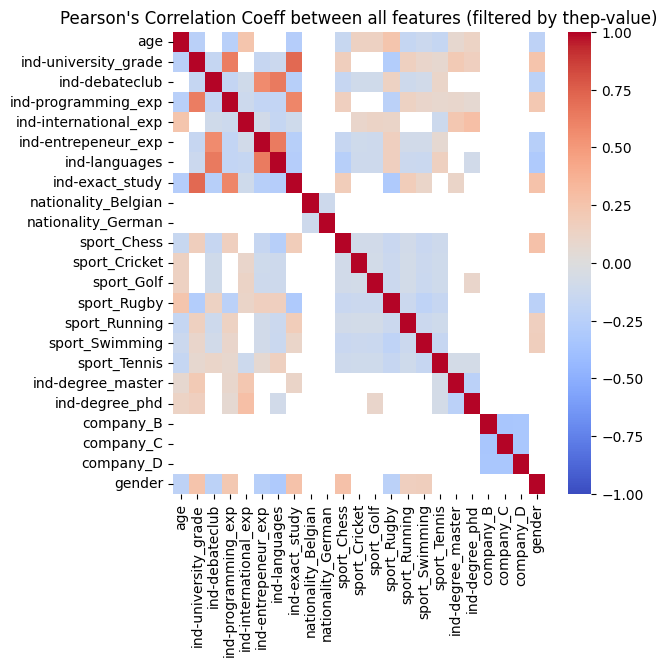

In [38]:
### Visualise full correlarion matrix
plt.figure(figsize=(6,6))
sns.heatmap(corr, cmap="coolwarm", xticklabels=X_train_copy.columns, yticklabels=X_train_copy.columns, mask= p > corrected_alpha, vmin=-1, vmax=1) ## mask if p is higher
plt.title("Pearson's Correlation Coeff between all features (filtered by thep-value)")
plt.show()

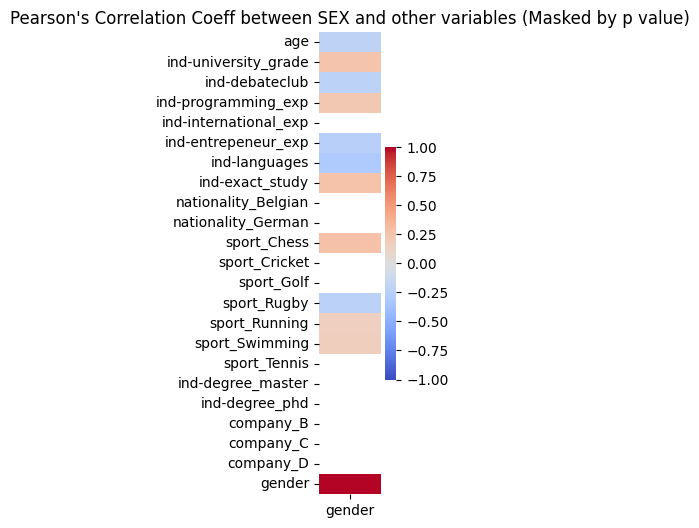

In [39]:
### Visualise columns of the correlation matrix that are associated only with protected features (see Lecture Slides)
plt.figure(figsize=(1,6))
sns.heatmap(corr[:, n:], cmap="coolwarm", xticklabels=X_train_copy.columns[n:], yticklabels=X_train_copy.columns,  mask = p[:, n:]  > corrected_alpha, vmin=-1, vmax=1)
plt.title("Pearson's Correlation Coeff between SEX and other variables (Masked by p value)")
plt.show()

### PCA <a id="pca"></a>

In [41]:
class FairPCA:
    def __init__(self, Xs, p_idxs, n_components, Y, fairness_metric = "statistical_parity"):
        self.fairness_metric = fairness_metric
        self.fit(Xs, p_idxs, n_components, fairness_metric, Y)

    def fit(self, Xs, p_idxs, n_components, fairness_metric, Y):
        # Extract protected features
        Xs_p = Xs[:, p_idxs]

        # In the article they only consider the case of statistical parity, but in section 3.2 they metion that it can be extended Equal Opportunity (almost the same as equalised odds but only for the true positive rates).
        # For equal opportunity we simply filter the data, such that we only create the projection based on the sample with positive outcomes. 
        if self.fairness_metric == "statistical_parity": 
            pass
        elif self.fairness_metric == "equalised_odds":
            Xs_p = Xs_p[Y == 1]
            Xs = Xs[Y == 1]
        else:
            print("Fairness metric not supported. Please choose between 'statistical_parity' and 'equalised_odds'.")

        # Compute projection matrix (U)
        Z = Xs_p
        #Z = Z - Z.mean(0) # Since we already standardised everything, there is not much sense in removing the mean
        R = scipy.linalg.null_space(Z.T @ Xs)
        eig_vals, L = scipy.linalg.eig(R.T @ Xs.T @ Xs @ R)
        self.U = R @ L[:, :n_components]
        self.eig_vals = eig_vals

    def project(self, Xs):
        return Xs @ self.U
    
n_components = 15
fair_pca = FairPCA(Xs_train, [n], n_components, y_train)
Xs_train_debiased = fair_pca.project(Xs_train)
Xs_test_debiased = fair_pca.project(Xs_test)

In [42]:
fair_pca.eig_vals

array([6672.66663989+0.j, 6054.03233528+0.j,  639.66922304+0.j,
        742.81049828+0.j, 1013.78099768+0.j, 1030.11783666+0.j,
       1294.07045131+0.j, 1341.70453882+0.j, 1390.83328445+0.j,
       1919.01010273+0.j, 4386.42014121+0.j, 2463.86717581+0.j,
       4227.76236711+0.j, 4098.46599812+0.j, 3891.93127841+0.j,
       2728.54543688+0.j, 2884.77824329+0.j, 3713.3695333 +0.j,
       3292.92737875+0.j, 3361.01995404+0.j, 3454.40748331+0.j,
       3415.77419151+0.j])

In [43]:
np.sort(fair_pca.eig_vals)

array([ 639.66922304+0.j,  742.81049828+0.j, 1013.78099768+0.j,
       1030.11783666+0.j, 1294.07045131+0.j, 1341.70453882+0.j,
       1390.83328445+0.j, 1919.01010273+0.j, 2463.86717581+0.j,
       2728.54543688+0.j, 2884.77824329+0.j, 3292.92737875+0.j,
       3361.01995404+0.j, 3415.77419151+0.j, 3454.40748331+0.j,
       3713.3695333 +0.j, 3891.93127841+0.j, 4098.46599812+0.j,
       4227.76236711+0.j, 4386.42014121+0.j, 6054.03233528+0.j,
       6672.66663989+0.j])

In [43]:
np.sum(fair_pca.eig_vals)

np.complex128(64017.96508987018+0j)

In [44]:
percent_var_eig = np.sort(fair_pca.eig_vals) / np.sum(fair_pca.eig_vals)
percent_var_eig

array([0.00999203+0.j, 0.01160316+0.j, 0.01583588+0.j, 0.01609107+0.j,
       0.02021418+0.j, 0.02095825+0.j, 0.02172567+0.j, 0.02997612+0.j,
       0.03848712+0.j, 0.04262156+0.j, 0.04506201+0.j, 0.05143755+0.j,
       0.0525012 +0.j, 0.05335649+0.j, 0.05395997+0.j, 0.05800512+0.j,
       0.06079436+0.j, 0.06402056+0.j, 0.06604025+0.j, 0.06851858+0.j,
       0.09456771+0.j, 0.10423116+0.j])

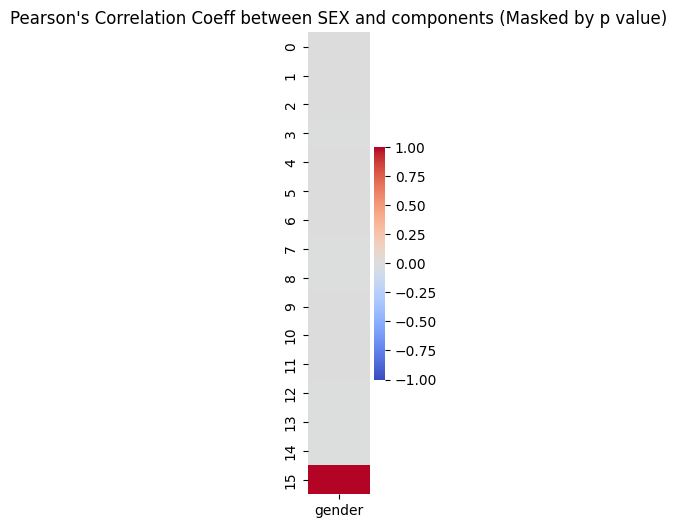

In [45]:
# Compute correlation matrix
Xs_train_debiased_p = np.concatenate([Xs_train_debiased, Xs_train_p], axis=1)
n_features = Xs_train_debiased_p.shape[1]
corr_ = np.zeros((n_features, n_features))
p_ = np.zeros((n_features, n_features))
for i in range(n_features):
    for j in range(n_features):
        corr_[i,j], p_[i,j] = pearsonr(Xs_train_debiased_p[:,i], Xs_train_debiased_p[:,j])
        corr_ = np.nan_to_num(corr_, 0)

# Plot correlations with protected features
plt.figure(figsize=(1,6))
sns.heatmap(corr_[:,-1:], cmap="coolwarm", xticklabels=X_train_copy.columns[-1:], vmin=-1, vmax=1)
plt.title("Pearson's Correlation Coeff between SEX and components (Masked by p value)")
plt.show()

In [46]:
group_test_dict = {
    'Males': group_test == 'male',
    'Females': group_test  == 'female',
}

In [47]:
# Fit model and predict
model = LogisticRegression(penalty=None, max_iter=1000)
model.fit(Xs_train_debiased, y_train)
y_hat = model.predict(Xs_test_debiased)

# Calculate and print F1 Scores for each group https://en.wikipedia.org/wiki/F-score
for group, group_idxs in group_test_dict.items():
    print(f'F1, {group}: {f1_score(y_test[group_idxs], y_hat[group_idxs]):.2f}')
print("\n")
# Calculate and print selection rates for each group
for group, group_idxs in group_test_dict.items():
    print(f'Selection Rate, {group}: {np.mean(y_hat[group_idxs]):.2f}')
print("\n")
# Calculate and print true positive rates for each group
for group, group_idxs in group_test_dict.items():
    print(f'True Positive Rate, {group}: {np.mean(y_hat[group_idxs][y_test[group_idxs] == 1]):.2f}')
print("\n")
# Calculate and print false positive rates for each group
for group, group_idxs in group_test_dict.items():
    print(f'False Positive Rate, {group}: {np.mean(y_hat[group_idxs][y_test[group_idxs] == 0]):.2f}')

F1, Males: 0.54
F1, Females: 0.39


Selection Rate, Males: 0.25
Selection Rate, Females: 0.16


True Positive Rate, Males: 0.47
True Positive Rate, Females: 0.32


False Positive Rate, Males: 0.14
False Positive Rate, Females: 0.11


In [48]:
#How does the results differ for different fairness metrics?

fairness_metrics = ["statistical_parity", "equalised_odds"]

for metric in fairness_metrics:
    fair_pca = FairPCA(Xs_train, [n], 20, y_train, fairness_metric = metric)
    Xs_train_debiased = fair_pca.project(Xs_train)
    Xs_test_debiased = fair_pca.project(Xs_test)

    model = LogisticRegression(penalty=None, max_iter=1000)
    model.fit(Xs_train_debiased, y_train)
    y_hat = model.predict(Xs_test_debiased)
    print(f"Fairness metric: {metric}\n")

    for group, group_idxs in group_test_dict.items():
        print(f'Selection Rate, {group}: {np.mean(y_hat[group_idxs]):.2f}')
    print("")
    for group, group_idxs in group_test_dict.items():
        print(f'True Positive Rate, {group}: {np.mean(y_hat[group_idxs][y_test[group_idxs] == 1]):.2f}')
    print("")
    for group, group_idxs in group_test_dict.items():
        print(f'False Positive Rate, {group}: {np.mean(y_hat[group_idxs][y_test[group_idxs] == 0]):.2f}')
    print("")

Fairness metric: statistical_parity

Selection Rate, Males: 0.26
Selection Rate, Females: 0.17

True Positive Rate, Males: 0.48
True Positive Rate, Females: 0.35

False Positive Rate, Males: 0.15
False Positive Rate, Females: 0.10

Fairness metric: equalised_odds

Selection Rate, Males: 0.25
Selection Rate, Females: 0.17

True Positive Rate, Males: 0.46
True Positive Rate, Females: 0.38

False Positive Rate, Males: 0.14
False Positive Rate, Females: 0.09



In [129]:
data.columns

Index(['age', 'ind-university_grade', 'ind-debateclub', 'ind-programming_exp',
       'ind-international_exp', 'ind-entrepeneur_exp', 'ind-languages',
       'ind-exact_study', 'gender_female', 'nationality_Belgian',
       'nationality_German', 'sport_Chess', 'sport_Cricket', 'sport_Golf',
       'sport_Rugby', 'sport_Running', 'sport_Swimming', 'sport_Tennis',
       'ind-degree_master', 'ind-degree_phd', 'company_B', 'company_C',
       'company_D'],
      dtype='object')

In [49]:
df_log_pca = X_test.copy()
df_log_pca['pred'] = y_hat

fem: 0.1686046511627907
male: 0.24545454545454545
ratio (fem/male): 0.6869078380706287
Difference in sts. parity: 0.07684989429175476


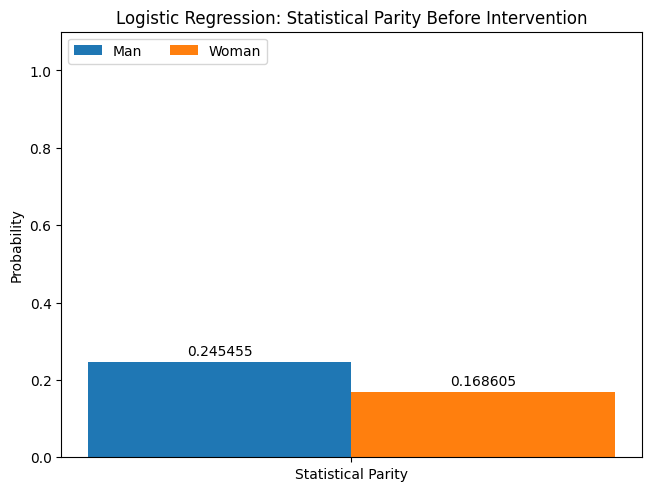

In [50]:
selection_col = 'pred'

fem_sp_bef = statistical_parity(df_log_pca, group=group_fem_label)
male_sp_bef = statistical_parity(df_log_pca, group=group_male_label)

print(f'fem: {fem_sp_bef}')
print(f'male: {male_sp_bef}')
print(f'ratio (fem/male): {fem_sp_bef/male_sp_bef}')

stats_parity_diff = male_sp_bef - fem_sp_bef

print(f'Difference in sts. parity: {stats_parity_diff}')
labels = ["Statistical Parity"]
medians = {
    'Man': male_sp_bef,
    'Woman': fem_sp_bef
}

x = np.arange(len(labels))
width = 0.2
multiplier = 0

fig, ax = plt.subplots(layout='constrained')

for attribute, measurement in medians.items():
    offset = width*multiplier
    rects = ax.bar(x + offset, measurement, width, label=attribute)
    ax.bar_label(rects, padding=3)
    multiplier += 1

ax.set_ylabel('Probability')
ax.set_title('Logistic Regression: Statistical Parity Before Intervention')
ax.set_xticks(x+width /2)
ax.set_xticklabels(labels)
ax.legend(loc='upper left', ncols=3)
ax.set_ylim(0, 1.1)

plt.show()

In [51]:
fem_eo_true_bef_no_gender = equalized_odds(df_log_pca, group_fem_label, target=True)
male_eo_true_bef_no_gender = equalized_odds(df_log_pca, group_male_label, target=True)

print(f'fem: {fem_eo_true_bef_no_gender}')
print(f'male: {male_eo_true_bef_no_gender}')
print(f'ratio (fem/male): {fem_eo_true_bef_no_gender/male_eo_true_bef_no_gender}')

fem_eo_false_bef_no_gender = equalized_odds(df_log_pca, group_fem_label, target=False)
male_eo_false_bef_no_gender = equalized_odds(df_log_pca, group_male_label, target=False)

print(f'fem: {fem_eo_false_bef_no_gender}')
print(f'male: {male_eo_false_bef_no_gender}')
print(f'ratio (fem/male): {fem_eo_false_bef_no_gender/male_eo_false_bef_no_gender}')

labels = ("target", "non_target")
medians = {
    'Man': (male_eo_true_bef_no_gender, male_eo_false_bef_no_gender),
    'Woman': (fem_eo_true_bef_no_gender, fem_eo_false_bef_no_gender)
}


x = np.arange(len(labels))
width = 0.2
multiplier = 0

fig, ax = plt.subplots(layout='constrained')

for attribute, measurement in medians.items():
    offset = width*multiplier
    rects = ax.bar(x + offset, measurement, width, label=attribute)
    ax.bar_label(rects, padding=3)
    multiplier += 1

ax.set_ylabel('Odds')
ax.set_title('Logistic Regression: Equalized Odds After Removing Gender')
ax.set_xticks(x+width/2, labels)
ax.legend(loc='upper left', ncols=3)
ax.set_ylim(0, 1.1)

plt.show()

KeyError: 'target'

In [53]:
Xs_test_debiased

array([[ 1.11697664, -2.65696837, -0.22966691, ..., -0.48152701,
         1.24372199,  0.18445089],
       [ 0.20737889,  0.71806603,  0.68110592, ...,  0.96486305,
         1.52044737, -0.11844939],
       [-0.55381662, -1.24647201,  0.3565991 , ..., -0.6387789 ,
         1.44340003, -0.29906253],
       ...,
       [ 0.34317542,  1.73762425,  0.19140921, ..., -0.19362236,
        -0.36440833, -0.93128127],
       [-1.44309881, -1.80345623,  0.33651006, ..., -0.67563994,
        -0.05057755,  0.81382126],
       [ 0.50643564, -1.29234186,  0.25706818, ..., -0.45750885,
        -0.29060278,  0.51084816]])

In [56]:
Xs_test_debiased[0,:]

array([ 1.11697664e+00, -2.65696837e+00, -2.29666911e-01,  1.85560207e-03,
        2.36520062e-01, -7.23642844e-02,  6.09789743e-01,  5.50274534e-02,
        8.09310835e-01, -4.54563517e-01, -1.54072120e-01,  1.30593526e+00,
       -1.55804129e+00,  4.24507557e-01, -6.91469940e-01,  1.95056743e-01,
        5.21774135e-02, -4.81527011e-01,  1.24372199e+00,  1.84450891e-01])

In [69]:
Xs_test_debiased

array([[ 1.11697664, -2.65696837, -0.22966691, ..., -0.48152701,
         1.24372199,  0.18445089],
       [ 0.20737889,  0.71806603,  0.68110592, ...,  0.96486305,
         1.52044737, -0.11844939],
       [-0.55381662, -1.24647201,  0.3565991 , ..., -0.6387789 ,
         1.44340003, -0.29906253],
       ...,
       [ 0.34317542,  1.73762425,  0.19140921, ..., -0.19362236,
        -0.36440833, -0.93128127],
       [-1.44309881, -1.80345623,  0.33651006, ..., -0.67563994,
        -0.05057755,  0.81382126],
       [ 0.50643564, -1.29234186,  0.25706818, ..., -0.45750885,
        -0.29060278,  0.51084816]])

In [70]:
df_Xs_test_debiased = pd.DataFrame(Xs_test_debiased, columns=['feat1', 'feat2', 'feat3', 'feat4', 'feat5', 'feat6', 'feat7', 'feat8', 'feat9', 'feat10', 'feat11', 'feat12', 'feat13', 'feat14', 'feat15', 'feat16', 'feat17', 'feat18', 'feat19', 'feat20'])

In [72]:
df_Xs_test_debiased.iloc[0,:]

feat1     1.116977
feat2    -2.656968
feat3    -0.229667
feat4     0.001856
feat5     0.236520
feat6    -0.072364
feat7     0.609790
feat8     0.055027
feat9     0.809311
feat10   -0.454564
feat11   -0.154072
feat12    1.305935
feat13   -1.558041
feat14    0.424508
feat15   -0.691470
feat16    0.195057
feat17    0.052177
feat18   -0.481527
feat19    1.243722
feat20    0.184451
Name: 0, dtype: float64

In [59]:
explainer_pca.expected_value

0.2259814873922758

In [61]:
shap_values_pca

array([ 0.06799226,  0.12081831,  0.01169496, -0.09621864, -0.01851461,
       -0.00925329, -0.18438002, -0.00674812,  0.20750581, -0.16994525,
        0.        , -0.12787941, -0.00684222, -0.00516271,  0.02410563,
       -0.00613615, -0.01966453, -0.0174843 ,  0.03290251, -0.02277171])

In [59]:
Xs_train_debiased[0]

array([-1.16959196, -2.86639748,  0.47437717, -0.3071408 ,  0.6222753 ,
        0.76757103,  0.43109546, -0.02566173, -0.42600415, -0.50295306,
        0.30887054, -0.85350938, -0.86765598, -1.33812516, -1.62679725])

In [75]:
df_Xs_train_debiased = pd.DataFrame(Xs_train_debiased, columns=['feat1', 'feat2', 'feat3', 'feat4', 'feat5', 'feat6', 'feat7', 'feat8', 'feat9', 'feat10', 'feat11', 'feat12', 'feat13', 'feat14', 'feat15', 'feat16', 'feat17', 'feat18', 'feat19', 'feat20'])

Using 3133 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


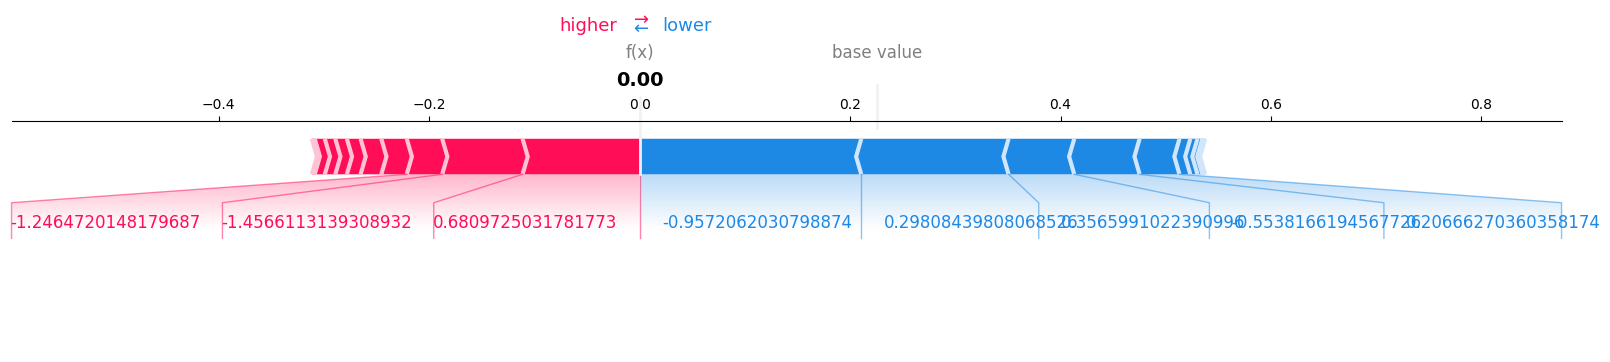

In [68]:
shap.initjs()

explainer_pca = shap.KernelExplainer(model=model.predict, data=Xs_train_debiased)

# get shapley values for one instance
shap_values_pca = explainer_pca.shap_values(Xs_test_debiased[2,:])

# plot
# shap.force_plot(explainer_pca.expected_value[1], shap_values_pca[1], Xs_test_debiased[0,:])
shap.force_plot(explainer_pca.expected_value, shap_values_pca, Xs_test_debiased[2,:], matplotlib=True)

In [78]:
shap.initjs()

explainer_pca = shap.KernelExplainer(model=model.predict, data=df_Xs_train_debiased)

# get shapley values for one instance
shap_values_pca = explainer_pca.shap_values(df_Xs_test_debiased.iloc[0,:])

# plot
# shap.force_plot(explainer_pca.expected_value[1], shap_values_pca[1], Xs_test_debiased[0,:])
# shap.force_plot(explainer_pca.expected_value, shap_values_pca[0], df_Xs_test_debiased.iloc[0,:], matplotlib=True)

Using 3133 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


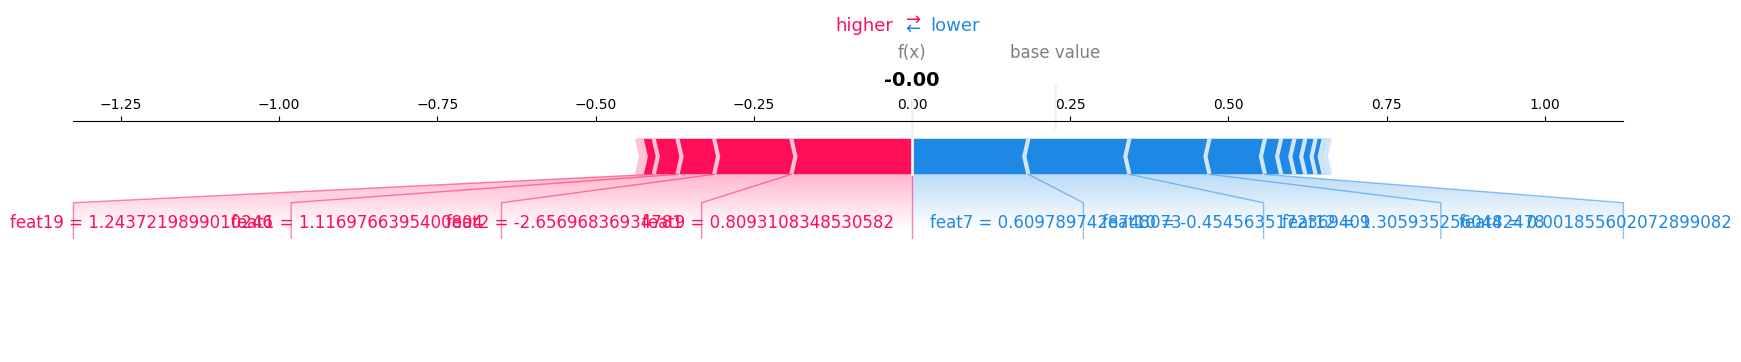

In [84]:
shap.force_plot(explainer_pca.expected_value, shap_values_pca, df_Xs_test_debiased.iloc[0,:], matplotlib=True)

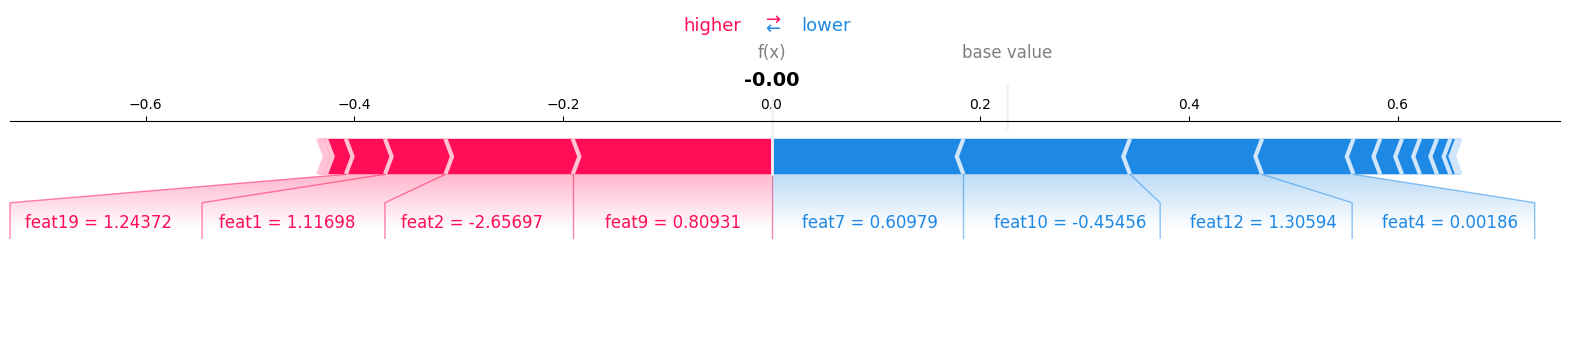

In [83]:
shap.force_plot(explainer_pca.expected_value, shap_values_pca, df_Xs_test_debiased.iloc[0,:].round(5), matplotlib=True)

In [85]:
shap.initjs()

explainer_pca = shap.KernelExplainer(model=model.predict, data=df_Xs_train_debiased)

# get shapley values for one instance
shap_values_pca = explainer_pca.shap_values(df_Xs_test_debiased.iloc[2,:])

Using 3133 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


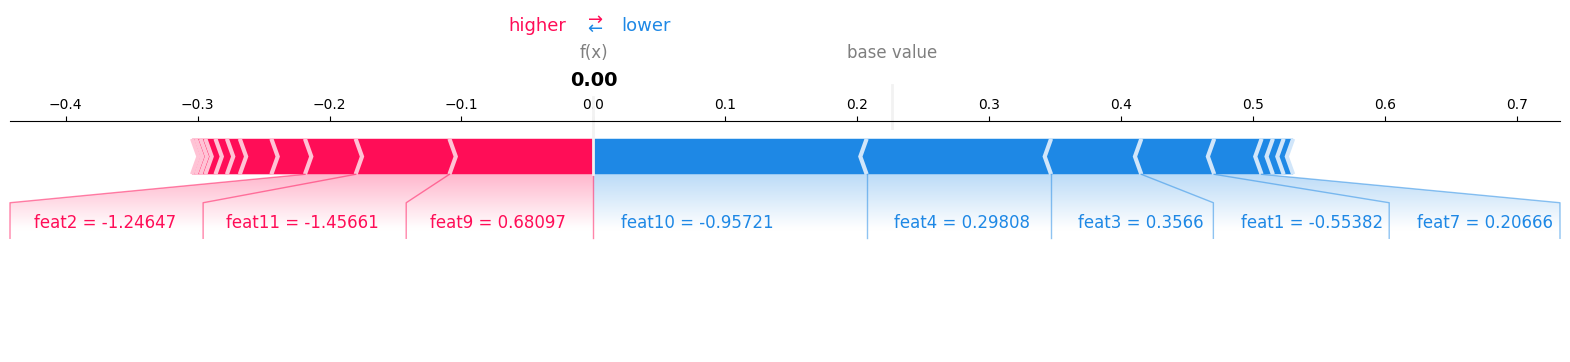

In [86]:
shap.force_plot(explainer_pca.expected_value, shap_values_pca, df_Xs_test_debiased.iloc[2,:].round(5), matplotlib=True)

In [98]:
shap_values_pca = explainer_pca.shap_values(df_Xs_test_debiased.iloc[4,:])

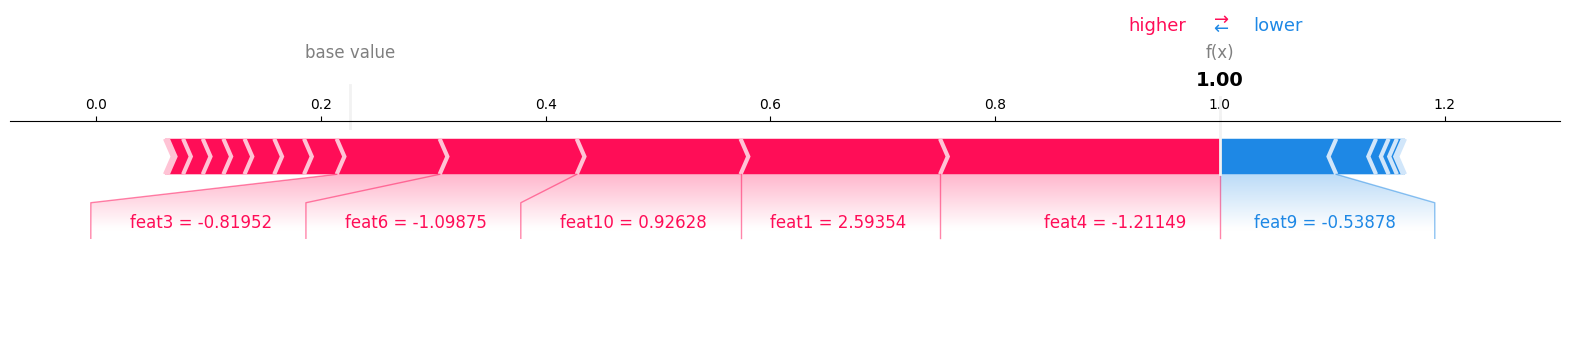

In [99]:
shap.force_plot(explainer_pca.expected_value, shap_values_pca, df_Xs_test_debiased.iloc[4,:].round(5), matplotlib=True)

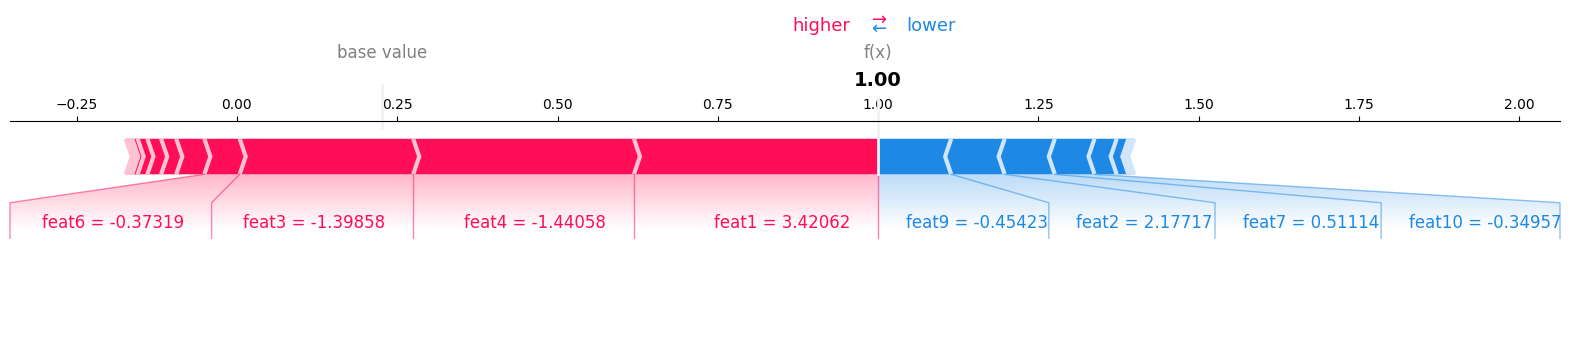

In [100]:
shap_values_pca = explainer_pca.shap_values(df_Xs_test_debiased.iloc[17,:])
shap.force_plot(explainer_pca.expected_value, shap_values_pca, df_Xs_test_debiased.iloc[17,:].round(5), matplotlib=True)

In [109]:
shap_values_pca

array([ 0.38095871, -0.0833833 ,  0.27057879,  0.34419941, -0.01826676,
        0.05512279, -0.07823528,  0.00840491, -0.11383408, -0.06191872,
       -0.03457442,  0.01525784,  0.00469261, -0.00479837,  0.02138139,
        0.00548081,  0.02358189,  0.        ,  0.04377861, -0.00440834])

In [108]:
shap.plots.waterfall(shap_values_pca)

TypeError: The waterfall plot requires an `Explanation` object as the `shap_values` argument.

In [107]:
shap.waterfall_plot(explainer_pca.expected_value, shap_values_pca, df_Xs_test_debiased.iloc[17,:].round(5))

TypeError: The waterfall plot requires an `Explanation` object as the `shap_values` argument.

In [75]:
test_df.head(23)

,gender,decision
0,female,True
1,female,False
2,male,True
3,male,False
4,male,True
5,female,False
6,male,False
7,male,False
8,female,False
9,male,False


In [74]:
y_hat

array([False, False, False, False,  True, False, False, False, False,
       False, False, False, False,  True, False, False,  True,  True,
       False, False, False, False,  True, False,  True,  True, False,
       False, False,  True, False,  True, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
        True, False,  True,  True,  True, False, False, False, False,
       False, False, False, False, False, False, False,  True,  True,
       False, False,  True, False, False, False, False, False,  True,
       False,  True, False, False, False, False, False,  True,  True,
       False,  True, False, False, False, False,  True, False, False,
       False, False, False, False, False,  True,  True, False, False,
       False,  True, False, False, False,  True, False, False,  True,
        True, False, False, False, False, False,  True,  True, False,
       False, False,

In [103]:
df_log_pca

,age,ind-university_grade,ind-debateclub,ind-programming_exp,ind-international_exp,ind-entrepeneur_exp,ind-languages,ind-exact_study,gender_female,nationality_Belgian,...,sport_Rugby,sport_Running,sport_Swimming,sport_Tennis,ind-degree_master,ind-degree_phd,company_B,company_C,company_D,pred
546,25,59,True,False,False,True,2,False,True,False,...,True,False,False,False,False,False,False,False,False,False
3140,28,62,False,False,False,False,1,True,True,False,...,False,False,True,False,True,False,False,False,True,False
837,30,56,True,False,False,False,2,False,False,False,...,True,False,False,False,False,False,False,False,False,False
937,27,68,False,True,False,False,1,True,False,True,...,False,False,False,False,False,False,False,False,False,False
3790,24,67,True,False,False,True,3,False,False,True,...,False,False,True,False,True,False,False,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1306,27,59,False,False,True,False,1,False,False,False,...,False,False,False,False,True,False,True,False,False,False
788,24,58,True,False,False,True,3,False,False,False,...,False,False,False,True,True,False,False,False,False,True
3394,25,69,False,True,False,False,1,True,True,False,...,False,False,False,False,True,False,False,False,True,False
1826,32,62,False,False,True,False,1,False,True,False,...,True,False,False,False,True,False,True,False,False,False


In [48]:
dummy_test = X_test_copy.iloc[:1]
dummy_test

,age,ind-university_grade,ind-debateclub,ind-programming_exp,ind-international_exp,ind-entrepeneur_exp,ind-languages,ind-exact_study,nationality_Belgian,nationality_German,...,sport_Rugby,sport_Running,sport_Swimming,sport_Tennis,ind-degree_master,ind-degree_phd,company_B,company_C,company_D,gender
546,25,59,True,False,False,True,2,False,False,False,...,True,False,False,False,False,False,False,False,False,True


In [49]:
dummy_test = pd.concat([dummy_test, dummy_test], ignore_index=True)
dummy_test

,age,ind-university_grade,ind-debateclub,ind-programming_exp,ind-international_exp,ind-entrepeneur_exp,ind-languages,ind-exact_study,nationality_Belgian,nationality_German,...,sport_Rugby,sport_Running,sport_Swimming,sport_Tennis,ind-degree_master,ind-degree_phd,company_B,company_C,company_D,gender
0,25,59,True,False,False,True,2,False,False,False,...,True,False,False,False,False,False,False,False,False,True
1,25,59,True,False,False,True,2,False,False,False,...,True,False,False,False,False,False,False,False,False,True


In [ ]:
# This is originally a Female who is not selected
dummy_test.loc[1, 'gender'] = False
dummy_test
# now, row 0 is True (Female) and row 1 is False (Male) 

,age,ind-university_grade,ind-debateclub,ind-programming_exp,ind-international_exp,ind-entrepeneur_exp,ind-languages,ind-exact_study,nationality_Belgian,nationality_German,...,sport_Rugby,sport_Running,sport_Swimming,sport_Tennis,ind-degree_master,ind-degree_phd,company_B,company_C,company_D,gender
0,25,59,True,False,False,True,2,False,False,False,...,True,False,False,False,False,False,False,False,False,True
1,25,59,True,False,False,True,2,False,False,False,...,True,False,False,False,False,False,False,False,False,False


In [51]:
Xs_dummy_test = scaler.transform(dummy_test)

In [ ]:
Xs_dummy_test_debiased = fair_pca.project(Xs_dummy_test)

In [53]:
Xs_dummy_test

array([[-0.40623358, -0.57084514,  1.79986468, -0.69478485, -0.54082506,
         1.85071371,  0.77469914, -0.93777615, -0.35062668, -0.32661305,
        -0.31816698, -0.2867241 , -0.29190677,  2.2364963 , -0.28867513,
        -0.45787827, -0.35577124, -0.8901315 , -0.25692187, -0.5796845 ,
        -0.58607337, -0.57280462,  1.08012345],
       [-0.40623358, -0.57084514,  1.79986468, -0.69478485, -0.54082506,
         1.85071371,  0.77469914, -0.93777615, -0.35062668, -0.32661305,
        -0.31816698, -0.2867241 , -0.29190677,  2.2364963 , -0.28867513,
        -0.45787827, -0.35577124, -0.8901315 , -0.25692187, -0.5796845 ,
        -0.58607337, -0.57280462, -0.9258201 ]])

In [54]:
Xs_dummy_test_debiased

array([[-1.54784048,  2.71567302, -0.21173088, -0.55629365, -1.26227341,
        -0.38120572, -0.31805844, -0.15645862,  0.36623513,  1.06974702,
        -0.77982356,  1.1754201 , -0.15940063, -0.64132223,  0.31379435],
       [-1.41230626,  1.78813755, -0.14675337, -0.71712755, -1.24662905,
        -0.46113365, -0.35802661, -0.23907384,  0.33332612,  0.94811174,
        -0.47348486,  0.71305715, -0.17045553, -0.42106661,  0.12545079]])

In [60]:
df_Xs_train_debiased = pd.DataFrame(Xs_train_debiased, columns=['feat1', 'feat2', 'feat3', 'feat4', 'feat5', 'feat6', 'feat7', 'feat8', 'feat9', 'feat10', 'feat11', 'feat12', 'feat13', 'feat14', 'feat15'])

In [56]:
# df_Xs_dummy_test_debiased = pd.DataFrame(Xs_dummy_test_debiased, columns=['feat1', 'feat2', 'feat3', 'feat4', 'feat5', 'feat6', 'feat7', 'feat8', 'feat9', 'feat10', 'feat11', 'feat12', 'feat13', 'feat14', 'feat15', 'feat16', 'feat17', 'feat18', 'feat19', 'feat20'])
df_Xs_dummy_test_debiased = pd.DataFrame(Xs_dummy_test_debiased, columns=['feat1', 'feat2', 'feat3', 'feat4', 'feat5', 'feat6', 'feat7', 'feat8', 'feat9', 'feat10', 'feat11', 'feat12', 'feat13', 'feat14', 'feat15'])

In [64]:
df_Xs_dummy_test_debiased

,feat1,feat2,feat3,feat4,feat5,feat6,feat7,feat8,feat9,feat10,feat11,feat12,feat13,feat14,feat15
0,-1.547840,2.715673,-0.211731,-0.556294,-1.262273,-0.381206,-0.318058,-0.156459,0.366235,1.069747,-0.779824,1.175420,-0.159401,-0.641322,0.313794
1,-1.412306,1.788138,-0.146753,-0.717128,-1.246629,-0.461134,-0.358027,-0.239074,0.333326,0.948112,-0.473485,0.713057,-0.170456,-0.421067,0.125451


In [61]:
shap.initjs()

explainer_pca = shap.KernelExplainer(model=model.predict, data=df_Xs_train_debiased)

# get shapley values for one instance
shap_values_pca_0 = explainer_pca.shap_values(df_Xs_dummy_test_debiased.iloc[0,:])
shap_values_pca_1 = explainer_pca.shap_values(df_Xs_dummy_test_debiased.iloc[1,:])

Using 3133 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


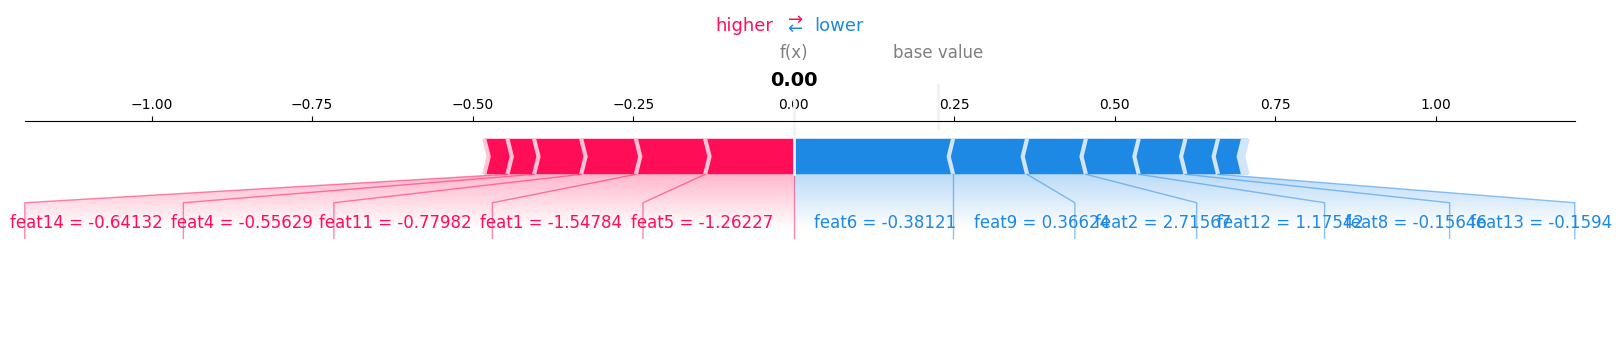

In [62]:
shap.force_plot(explainer_pca.expected_value, shap_values_pca_0, df_Xs_dummy_test_debiased.iloc[0,:].round(5), matplotlib=True)

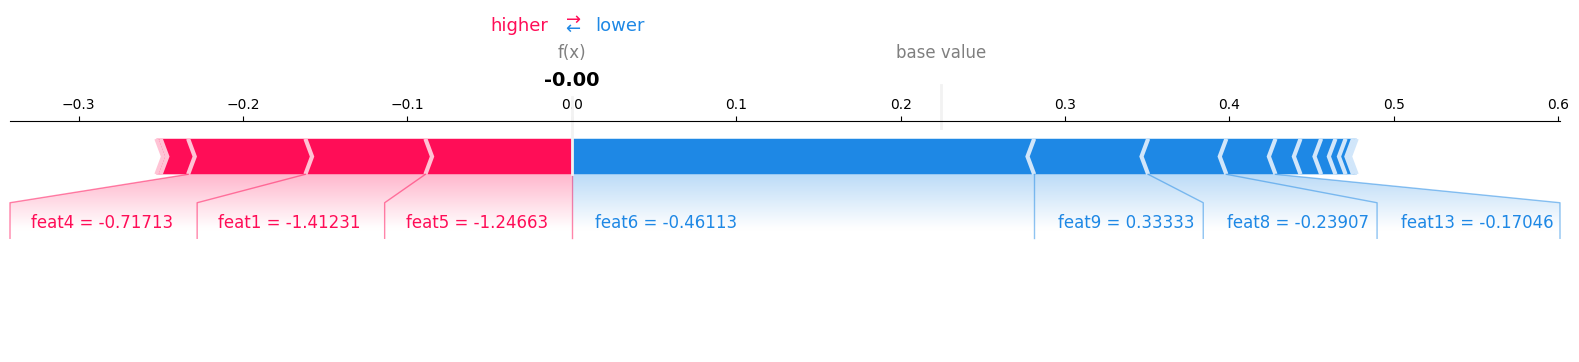

In [63]:
shap.force_plot(explainer_pca.expected_value, shap_values_pca_1, df_Xs_dummy_test_debiased.iloc[1,:].round(5), matplotlib=True)

In [80]:
dummy_test_2 = X_test_copy.iloc[4:5]
dummy_test_2

,age,ind-university_grade,ind-debateclub,ind-programming_exp,ind-international_exp,ind-entrepeneur_exp,ind-languages,ind-exact_study,nationality_Belgian,nationality_German,...,sport_Rugby,sport_Running,sport_Swimming,sport_Tennis,ind-degree_master,ind-degree_phd,company_B,company_C,company_D,gender
3790,24,67,True,False,False,True,3,False,True,False,...,False,False,True,False,True,False,False,False,True,False


In [81]:
dummy_test_2 = pd.concat([dummy_test_2, dummy_test_2], ignore_index=True)
# dummy_test

# This is originally a Male who is selected
dummy_test_2.loc[0, 'gender'] = True
dummy_test_2
# now, row 0 is True (Female) and row 1 is False (Male) 

,age,ind-university_grade,ind-debateclub,ind-programming_exp,ind-international_exp,ind-entrepeneur_exp,ind-languages,ind-exact_study,nationality_Belgian,nationality_German,...,sport_Rugby,sport_Running,sport_Swimming,sport_Tennis,ind-degree_master,ind-degree_phd,company_B,company_C,company_D,gender
0,24,67,True,False,False,True,3,False,True,False,...,False,False,True,False,True,False,False,False,True,True
1,24,67,True,False,False,True,3,False,True,False,...,False,False,True,False,True,False,False,False,True,False


In [82]:
Xs_dummy_test_2 = scaler.transform(dummy_test_2)
Xs_dummy_test_debiased_2 = fair_pca.project(Xs_dummy_test_2)

In [83]:
Xs_dummy_test_debiased_2

array([[-2.55973187,  1.32242428,  0.01635995, -0.86126826,  0.31199814,
         0.06475426,  0.40948066,  0.58372637, -0.54825335,  0.34995348,
        -0.72591891, -0.52463458, -0.28376129, -2.60822306,  0.30735775],
       [-2.42419765,  0.39488881,  0.08133746, -1.02210216,  0.32764249,
        -0.01517367,  0.36951249,  0.50111115, -0.58116236,  0.22831819,
        -0.4195802 , -0.98699753, -0.29481619, -2.38796743,  0.11901419]])

In [84]:
df_Xs_dummy_test_debiased_2 = pd.DataFrame(Xs_dummy_test_debiased_2, columns=['feat1', 'feat2', 'feat3', 'feat4', 'feat5', 'feat6', 'feat7', 'feat8', 'feat9', 'feat10', 'feat11', 'feat12', 'feat13', 'feat14', 'feat15'])

In [85]:
shap.initjs()

explainer_pca = shap.KernelExplainer(model=model.predict, data=df_Xs_train_debiased)

# get shapley values for one instance
shap_values_pca_0_2 = explainer_pca.shap_values(df_Xs_dummy_test_debiased_2.iloc[0,:])
shap_values_pca_1_2 = explainer_pca.shap_values(df_Xs_dummy_test_debiased_2.iloc[1,:])

Using 3133 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


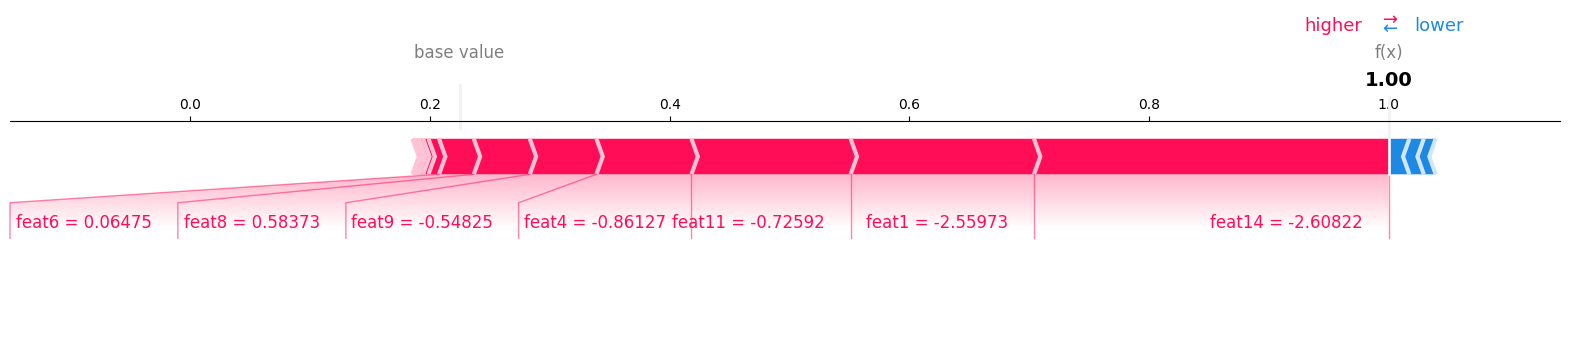

In [86]:
#woman
shap.force_plot(explainer_pca.expected_value, shap_values_pca_0_2, df_Xs_dummy_test_debiased_2.iloc[0,:].round(5), matplotlib=True)

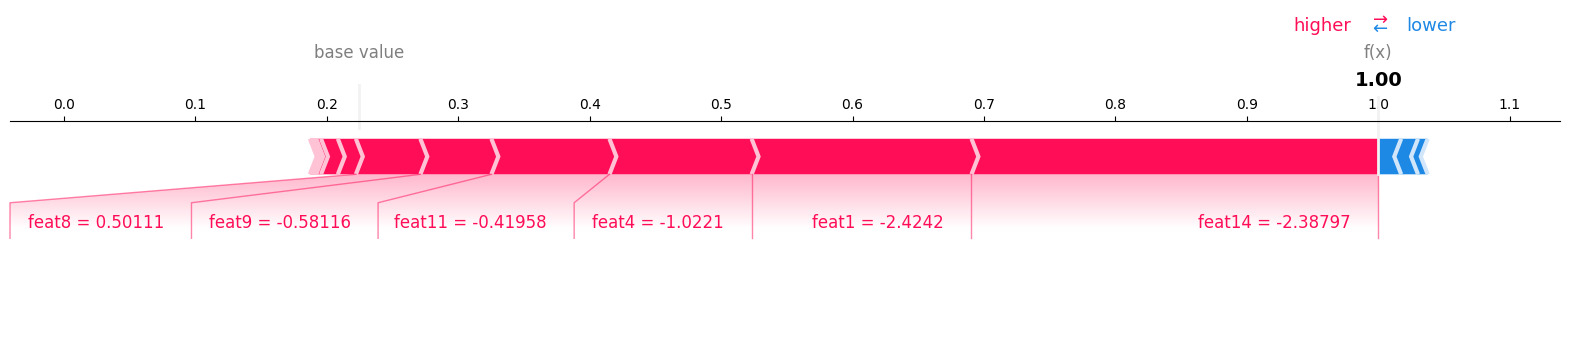

In [87]:
#male
shap.force_plot(explainer_pca.expected_value, shap_values_pca_1_2, df_Xs_dummy_test_debiased_2.iloc[1,:].round(5), matplotlib=True)

### Testing if flipping gender in test changes results

In [88]:
dummy_test_copy = X_test_copy.copy()

In [89]:
dummy_test_copy

,age,ind-university_grade,ind-debateclub,ind-programming_exp,ind-international_exp,ind-entrepeneur_exp,ind-languages,ind-exact_study,nationality_Belgian,nationality_German,...,sport_Rugby,sport_Running,sport_Swimming,sport_Tennis,ind-degree_master,ind-degree_phd,company_B,company_C,company_D,gender
546,25,59,True,False,False,True,2,False,False,False,...,True,False,False,False,False,False,False,False,False,True
3140,28,62,False,False,False,False,1,True,False,False,...,False,False,True,False,True,False,False,False,True,True
837,30,56,True,False,False,False,2,False,False,False,...,True,False,False,False,False,False,False,False,False,False
937,27,68,False,True,False,False,1,True,True,False,...,False,False,False,False,False,False,False,False,False,False
3790,24,67,True,False,False,True,3,False,True,False,...,False,False,True,False,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1306,27,59,False,False,True,False,1,False,False,True,...,False,False,False,False,True,False,True,False,False,False
788,24,58,True,False,False,True,3,False,False,False,...,False,False,False,True,True,False,False,False,False,False
3394,25,69,False,True,False,False,1,True,False,True,...,False,False,False,False,True,False,False,False,True,True
1826,32,62,False,False,True,False,1,False,False,False,...,True,False,False,False,True,False,True,False,False,True


In [90]:
dummy_test_copy['gender'] = ~dummy_test_copy['gender']
dummy_test_copy

,age,ind-university_grade,ind-debateclub,ind-programming_exp,ind-international_exp,ind-entrepeneur_exp,ind-languages,ind-exact_study,nationality_Belgian,nationality_German,...,sport_Rugby,sport_Running,sport_Swimming,sport_Tennis,ind-degree_master,ind-degree_phd,company_B,company_C,company_D,gender
546,25,59,True,False,False,True,2,False,False,False,...,True,False,False,False,False,False,False,False,False,False
3140,28,62,False,False,False,False,1,True,False,False,...,False,False,True,False,True,False,False,False,True,False
837,30,56,True,False,False,False,2,False,False,False,...,True,False,False,False,False,False,False,False,False,True
937,27,68,False,True,False,False,1,True,True,False,...,False,False,False,False,False,False,False,False,False,True
3790,24,67,True,False,False,True,3,False,True,False,...,False,False,True,False,True,False,False,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1306,27,59,False,False,True,False,1,False,False,True,...,False,False,False,False,True,False,True,False,False,True
788,24,58,True,False,False,True,3,False,False,False,...,False,False,False,True,True,False,False,False,False,True
3394,25,69,False,True,False,False,1,True,False,True,...,False,False,False,False,True,False,False,False,True,False
1826,32,62,False,False,True,False,1,False,False,False,...,True,False,False,False,True,False,True,False,False,False


In [93]:
Xs_dummy_test_copy = scaler.transform(dummy_test_copy)
Xs_dummy_test_debiased_copy = fair_pca.project(Xs_dummy_test_copy)
df_Xs_dummy_test_debiased_copy = pd.DataFrame(Xs_dummy_test_debiased_copy, columns=['feat1', 'feat2', 'feat3', 'feat4', 'feat5', 'feat6', 'feat7', 'feat8', 'feat9', 'feat10', 'feat11', 'feat12', 'feat13', 'feat14', 'feat15'])

In [101]:
# We swapped the genders
group_test_dict_dummy = {
    'Females_fake': group_test == 'male', #these are actually males, but we flipped them to be female for the experiment
    'Males_fake': group_test  == 'female', # these are actually female, but we flipped them to be male
}

In [102]:
group_test_dict_dummy

{'Females_fake': array([False, False,  True,  True,  True, False,  True,  True, False,
         True,  True,  True,  True, False,  True,  True,  True,  True,
         True, False,  True,  True, False,  True,  True,  True,  True,
         True, False,  True, False,  True,  True,  True,  True, False,
         True, False, False, False, False, False, False, False,  True,
        False, False, False, False,  True, False, False,  True, False,
        False, False,  True,  True, False,  True, False, False, False,
        False,  True, False,  True,  True,  True,  True, False, False,
         True,  True,  True, False,  True,  True,  True,  True,  True,
         True, False, False, False, False,  True, False,  True,  True,
        False,  True,  True,  True, False,  True, False,  True,  True,
         True,  True,  True,  True,  True,  True,  True, False, False,
        False, False, False,  True,  True,  True,  True, False,  True,
        False,  True,  True,  True,  True, False, False,  Tru

In [103]:
# model.fit(Xs_train_debiased, y_train)
y_hat_dummy = model.predict(Xs_dummy_test_debiased_copy)

# Calculate and print F1 Scores for each group https://en.wikipedia.org/wiki/F-score
for group, group_idxs in group_test_dict_dummy.items():
    print(f'F1, {group}: {f1_score(y_test[group_idxs], y_hat_dummy[group_idxs]):.2f}')
print("\n")
# Calculate and print selection rates for each group
for group, group_idxs in group_test_dict_dummy.items():
    print(f'Selection Rate, {group}: {np.mean(y_hat_dummy[group_idxs]):.2f}')
print("\n")
# Calculate and print true positive rates for each group
for group, group_idxs in group_test_dict_dummy.items():
    print(f'True Positive Rate, {group}: {np.mean(y_hat_dummy[group_idxs][y_test[group_idxs] == 1]):.2f}')
print("\n")
# Calculate and print false positive rates for each group
for group, group_idxs in group_test_dict_dummy.items():
    print(f'False Positive Rate, {group}: {np.mean(y_hat_dummy[group_idxs][y_test[group_idxs] == 0]):.2f}')

F1, Females_fake: 0.57
F1, Males_fake: 0.34


Selection Rate, Females_fake: 0.33
Selection Rate, Males_fake: 0.12


True Positive Rate, Females_fake: 0.57
True Positive Rate, Males_fake: 0.24


False Positive Rate, Females_fake: 0.21
False Positive Rate, Males_fake: 0.07
